# Part 1: Data Foundation and Descriptive Analysis
## Week 4: Descriptive Analysis

**Course:** DATA 6700 Independent Study, Summer 2026    
**Period:** June 8-14  
**Goals:**
- Patch: resolve four variables misclassified as Sparse due to column-name aliases across CHR releases
- National and state-level trend plots for the uninsured rate
- County-level distribution of the uninsured rate
- Correlation analysis of Core features against the outcome
- Extension: Medicaid expansion comparison of uninsured trajectories (2012-2025)

This notebook continues from Week 3. Sections 1-13 contain the panel construction work.
Sections 14 onward contain the Week 4 descriptive analysis.

---
## Section 1: Environment Setup

### Description
Import all libraries and configure display settings. No changes from Week 2 except the addition of `tabulate` for formatted summary tables.


In [1]:
import os
import warnings
from pathlib import Path
from datetime import date

import numpy as np
import pandas as pd


In [2]:
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.float_format', '{:.4f}'.format)


In [3]:
print(f'pandas {pd.__version__}  |  numpy {np.__version__}')

pandas 2.3.3  |  numpy 2.3.5


### Summary
Libraries imported and display settings configured.


---
## Section 2: Path Configuration

### Description
Reproduce the same directory structure and file map established in Week 2. All paths are relative to the project root so the notebook runs identically on any machine with the repo cloned.


In [4]:
import urllib.request

In [5]:
# GitHub repo base URL for raw file access
GITHUB_RAW_BASE = (
    'https://raw.githubusercontent.com/sphillips32/'
    'A-Longitudinal-Study-of-County-Health-Insurance-Coverage-2010-2025/'
    'main/data/raw'
)

# Local cache directory: files are downloaded here on first run
DATA_DIR   = Path('data/raw')
OUTPUT_DIR = Path('outputs')

In [6]:
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [7]:
def build_github_url(year, base=GITHUB_RAW_BASE):
    fname = YEAR_FILE_MAP[year]
    return base + 'data/raw/' + fname


def fetch_chr_file(year, data_dir=DATA_DIR):
    fname  = YEAR_FILE_MAP[year]
    local  = data_dir / fname
    if local.exists():
        return local, 'cached'
    url = build_github_url(year)
    try:
        urllib.request.urlretrieve(url, local)
        return local, 'downloaded'
    except Exception as exc:
        return None, f'ERROR: {exc}'

In [8]:
RELEASE_YEARS = list(range(2010, 2026))

print(f'GitHub source : {GITHUB_RAW_BASE}')
print(f'Local cache   : {DATA_DIR.resolve()}')
print(f'Output dir    : {OUTPUT_DIR.resolve()}')
print(f'Release years : {RELEASE_YEARS[0]}-{RELEASE_YEARS[-1]}  ({len(RELEASE_YEARS)} files expected)')

GitHub source : https://raw.githubusercontent.com/sphillips32/A-Longitudinal-Study-of-County-Health-Insurance-Coverage-2010-2025/main/data/raw
Local cache   : C:\Users\sethp\OneDrive\Documents\Education\Independent Study\Notebooks\Part 1\data\raw
Output dir    : C:\Users\sethp\OneDrive\Documents\Education\Independent Study\Notebooks\Part 1\outputs
Release years : 2010-2025  (16 files expected)


In [9]:
# Exact filename for each release year as stored in the repo
YEAR_FILE_MAP = {
    2010: 'analytic_data2010.csv',
    2011: 'analytic_data2011.csv',
    2012: 'analytic_data2012.csv',
    2013: 'analytic_data2013.csv',
    2014: 'analytic_data2014.csv',
    2015: 'analytic_data2015.csv',
    2016: 'analytic_data2016.csv',
    2017: 'analytic_data2017.csv',
    2018: 'analytic_data2018_0.csv',
    2019: 'analytic_data2019.csv',
    2020: 'analytic_data2020_0.csv',
    2021: 'analytic_data2021.csv',
    2022: 'analytic_data2022.csv',
    2023: 'analytic_data2023_0.csv',
    2024: 'analytic_data2024.csv',
    2025: 'analytic_data2025_v3.csv',
}

In [10]:
def build_github_url(year, base=GITHUB_RAW_BASE):
    """
    Build the raw GitHub URL for a given release year using the explicit file map.
    Update YEAR_FILE_MAP above if any filenames change in the repo.
    """
    filename = YEAR_FILE_MAP[year]
    return f'{base}/{filename}'

In [11]:
def fetch_chr_file(year, data_dir=DATA_DIR):
    """
    Return the local Path for a CHR file, downloading from GitHub if not cached.
    Skips the download if the file already exists locally.
    """
    url        = build_github_url(year)
    local_path = data_dir / url.split('/')[-1]

    if local_path.exists():
        return local_path, 'cached'

    try:
        urllib.request.urlretrieve(url, local_path)
        return local_path, 'downloaded'
    except Exception as e:
        return None, f'ERROR: {e}'

In [12]:
fetch_results = []

for yr in RELEASE_YEARS:
    path, status = fetch_chr_file(yr)
    fetch_results.append({'release_year': yr, 'status': status, 'path': str(path) if path else None})
    print(f'{yr}  {status}')

2010  cached
2011  cached
2012  cached
2013  cached
2014  cached
2015  cached
2016  cached
2017  cached
2018  cached
2019  cached
2020  cached
2021  cached
2022  cached
2023  cached
2024  cached
2025  cached


In [13]:
fetch_df = pd.DataFrame(fetch_results)

errors = fetch_df[fetch_df['status'].str.startswith('ERROR')]

if not errors.empty:
    print('Files that could not be fetched:')
    print(errors[['release_year', 'status']].to_string(index=False))
    print()
    print('Check that the filename pattern in build_github_url() matches your repo.')
else:
    print(f'All {len(RELEASE_YEARS)} files ready.')

All 16 files ready.


### Summary
All 16 CHR CSV files are available locally under `data/raw/`. Files already cached from Week 2 are not re-downloaded.


---
## Section 3: Load Reference Tables

### Description
Load the following tables from Week2:
- `release_measure_year_map.csv`
- `comparability_flags.csv`

The measure-year map is used later to attach `measure_year` to every panel row. The comparability flags document decisions already made and guide the filtering steps below.

In [14]:
measure_year_map = pd.read_csv(OUTPUT_DIR / 'release_measure_year_map.csv')

# Keep only the two columns needed for the join
measure_year_map = measure_year_map[['release_year', 'approx_measure_period']].copy()
measure_year_map.columns = ['release_year', 'measure_year']

# measure_year is stored as an integer for clean merging and plotting
measure_year_map['measure_year'] = measure_year_map['measure_year'].astype(int)

print(measure_year_map.to_string(index=False))

 release_year  measure_year
         2010          2005
         2011          2008
         2012          2009
         2013          2010
         2014          2011
         2015          2012
         2016          2013
         2017          2014
         2018          2015
         2019          2016
         2020          2017
         2021          2018
         2022          2019
         2023          2020
         2024          2021
         2025          2022


In [15]:
flags_df = pd.read_csv(OUTPUT_DIR / 'comparability_flags.csv')
print(flags_df[['flag_id', 'scope', 'action_taken']].to_string(index=False))

               flag_id                  scope                                                                                                                                                                            action_taken
               CT_2022            Connecticut Recommendation: exclude Connecticut. The split measure availability across planning regions and former counties makes a consistent longitudinal record not feasible for most variables.
  UNINSURED_COL_RENAME             All states                                               2025 confirmed: v059_rawvalue. 2012-2024: v085_rawvalue. 2010-2011: v003_rawvalue (adults only). Decision pending on 2010-2011 inclusion.
      MEASURE_YEAR_LAG           All measures                   All 15 years verified as SAHIE. Measurement years confirmed and recorded in release_measure_year_map.csv. 2024 is the only unverified year (codebook only available).
          SAHIE_VS_ACS             All states                                   

### Summary
Measurement-year map loaded and cast to integer. Comparability flags confirm the four decisions driving this notebook: exclude Connecticut, filter state summary rows, use `v085_rawvalue` (2012-2025) as the primary outcome, and carry `measure_year` as the time axis.


---
## Section 4: Column Name Standardization Maps

### Description
CHR column names changed across releases. This section defines three lookup dictionaries that map each release year's raw column names to standardized snake_case names used throughout the panel.

- **`FIPS_VARIANTS`**: the three FIPS column names seen across releases.
- **`UNINSURED_MAP`**: maps the three uninsured column variants to `uninsured_raw`.
- **`FEATURE_MAP`**: maps the long human-readable CHR column names to short, consistent feature names. Only the 14 socioeconomic and demographic predictors chosen for Part 1 are kept; health-behavior measures are excluded per project guidelines.

**Decision log entry:** The variables chosen are those with links to insurance in the CHR Documentation: income, poverty, education, labor-market attachment, household structure, housing cost burden, rurality, age composition, and race/ethnicity shares. Health-behavior measures (smoking, obesity, physical inactivity) are excluded because they would complicate the Part 1 interpretation.

In [16]:
# FIPS column name variants observed across 2010-2025 releases
FIPS_VARIANTS = [
    '5-digit fips code',
    'fipscode',
    'fips',
    'county fips',
]

In [17]:
# Uninsured column variants mapped to standardized names.
# CHR CSVs use measure-ID headers (row 1). Measure IDs are stable across all release years.
# v003 = adults-only (2010-2011), v085 = all-ages (2012-2024), v059 = all-ages (2025).
# The uninsured_renamed guard in load_chr_year prevents duplicate column names when
# both v085 and v059 appear in the same file.
UNINSURED_MAP = {
    'v003_rawvalue' : 'uninsured_adults_raw',   # 2010-2011 (adults-only)
    'v085_rawvalue' : 'uninsured_raw',           # 2012-2024 (all-ages)
    'v059_rawvalue' : 'uninsured_raw',           # 2025 (all-ages, measure renumbered)
}

In [18]:
# Socioeconomic and demographic feature columns selected for Part 1.
# Keys are CHR measure IDs verified against data dictionaries and confirmed
# stable across release years 2012-2025 via label-to-ID lookup on analytic_data2019.csv.
# poverty_rate (v118_rawvalue) removed: Wisconsin-only data submission, not a
# national county-level measure. See decision log for full justification.
FEATURE_MAP = {
    'v063_rawvalue' : 'median_income',
    'v024_rawvalue' : 'child_poverty_rate',
    'v044_rawvalue' : 'income_inequality',
    'v023_rawvalue' : 'unemployment_rate',
    'v021_rawvalue' : 'hs_graduation_rate',
    'v069_rawvalue' : 'some_college_rate',
    'v082_rawvalue' : 'single_parent_rate',
    'v136_rawvalue' : 'severe_housing_rate',
    'v058_rawvalue' : 'pct_rural',
    'v052_rawvalue' : 'pct_under18',
    'v053_rawvalue' : 'pct_65plus',
    'v054_rawvalue' : 'pct_black',
    'v055_rawvalue' : 'pct_aian',
    'v081_rawvalue' : 'pct_asian',
    'v056_rawvalue' : 'pct_hispanic',
    'v126_rawvalue' : 'pct_white',
    'v051_rawvalue' : 'population',
}

print(f'Feature columns targeted: {len(FEATURE_MAP)}')
for mid, tgt in FEATURE_MAP.items():
    print(f'  {mid:<20} -> {tgt}')

Feature columns targeted: 17
  v063_rawvalue        -> median_income
  v024_rawvalue        -> child_poverty_rate
  v044_rawvalue        -> income_inequality
  v023_rawvalue        -> unemployment_rate
  v021_rawvalue        -> hs_graduation_rate
  v069_rawvalue        -> some_college_rate
  v082_rawvalue        -> single_parent_rate
  v136_rawvalue        -> severe_housing_rate
  v058_rawvalue        -> pct_rural
  v052_rawvalue        -> pct_under18
  v053_rawvalue        -> pct_65plus
  v054_rawvalue        -> pct_black
  v055_rawvalue        -> pct_aian
  v081_rawvalue        -> pct_asian
  v056_rawvalue        -> pct_hispanic
  v126_rawvalue        -> pct_white
  v051_rawvalue        -> population


### Summary
Three name maps defined. The feature set covers 18 candidate predictors: income and poverty (3), education (2), labor market (1), household structure (1), housing (1), rurality (1), age composition (2), race/ethnicity shares (5), and population. All names are consistent snake_case strings that will persist through Parts 2 and 3.


---
## Section 5: Single-Year File Loader

### Description
Define `load_chr_year()`, which reads one CHR CSV, applies all row and column filters, and returns a DataFrame with standardized column names.

Steps performed inside the function:
1. Read the CSV with `dtype=str` to prevent FIPS zero-stripping.
2. Detect and rename the FIPS column to `fips`.
3. Drop state-summary rows (FIPS ending in `000`).
4. Exclude Connecticut (state FIPS prefix `09`).
5. Detect and rename the uninsured column.
6. Select and rename the available feature columns.
7. Add `release_year`.
8. Convert numeric columns from string to float.

In [19]:
def detect_col(df, variants):
    lower_map = {c.lower(): c for c in df.columns}
    for v in variants:
        v_lower = v.lower()
        # Exact match first
        if v_lower in lower_map:
            return lower_map[v_lower]
        # Partial match fallback
        for k, orig in lower_map.items():
            if v_lower in k:
                return orig
    return None

In [20]:
def load_chr_year(year):
    path, status = fetch_chr_file(year)
    if path is None:
        print(f'WARNING: {year} file unavailable ({status})')
        return None

    # header=1 skips the human-readable label row (row 0) and uses the
    # measure-ID row (row 1) as column names. All CHR CSVs 2010-2025 use
    # this two-row structure confirmed from data dictionaries.
    df = pd.read_csv(path, dtype=str, low_memory=False, header=1)

    # Remove the stray label row that becomes a data row when header=1.
    # It contains non-numeric text in fipscode; filtering to 5-digit numeric
    # FIPS values removes it cleanly alongside any other malformed rows.
    df = df[df['fipscode'].str.fullmatch(r'\d+', na=False)].copy()

    # --- FIPS ---
    fips_orig = detect_col(df, FIPS_VARIANTS)
    if fips_orig is None:
        print(f'WARNING: {year} - FIPS column not found; skipping')
        return None
    df = df.rename(columns={fips_orig: 'fips'})

    # Zero-pad FIPS to 5 characters
    df['fips'] = df['fips'].str.zfill(5)

    # Drop state summary rows (county portion = 000)
    df = df[df['fips'].str[2:].fillna('').ne('000')].copy()

    # Drop Connecticut (state FIPS = 09)
    df = df[~df['fips'].str.startswith('09').fillna(False)].copy()

    # --- Uninsured columns ---
    # Rename only the first matching variant for each standardized name.
    # Some release years contain both v085 and v059; the guard prevents
    # duplicate column names that would break pd.to_numeric downstream.
    uninsured_renamed = set()
    for raw_name, std_name in UNINSURED_MAP.items():
        if std_name in uninsured_renamed:
            continue
        orig = detect_col(df, [raw_name])
        if orig is not None:
            df = df.rename(columns={orig: std_name})
            uninsured_renamed.add(std_name)

    # --- Feature columns ---
    keep_cols = {'fips'}
    rename_dict = {}
    for raw_name, std_name in FEATURE_MAP.items():
        orig = detect_col(df, [raw_name])
        if orig is not None:
            rename_dict[orig] = std_name
            keep_cols.add(std_name)

    df = df.rename(columns=rename_dict)

    # Also keep any uninsured columns that were renamed above
    for std_name in UNINSURED_MAP.values():
        if std_name in df.columns:
            keep_cols.add(std_name)

    # Keep state abbreviation and county name for readability.
    # With header=1 these columns are named 'state' and 'county'.
    for orig_col, std_col in [('state', 'state_abbreviation'), ('county', 'name')]:
        if orig_col in df.columns:
            df = df.rename(columns={orig_col: std_col})
            keep_cols.add(std_col)

    # Subset to keep_cols that actually exist
    keep_cols = [c for c in keep_cols if c in df.columns]
    df = df[keep_cols].copy()

    # Add release year
    df['release_year'] = year

    # Convert all columns except identifiers to float
    id_cols = {'fips', 'state_abbreviation', 'name', 'release_year'}
    for col in df.columns:
        if col not in id_cols:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    return df

In [21]:
# Smoke-test on 2016 to confirm the loader works before stacking all years
test = load_chr_year(2016)
print(f'Shape: {test.shape}')
print(f'Columns: {list(test.columns)}')
print()
print(test.head(3).to_string())

Shape: (3133, 23)
Columns: ['population', 'state_abbreviation', 'pct_65plus', 'child_poverty_rate', 'severe_housing_rate', 'pct_asian', 'unemployment_rate', 'fips', 'pct_under18', 'median_income', 'pct_black', 'pct_hispanic', 'name', 'single_parent_rate', 'pct_rural', 'pct_aian', 'hs_graduation_rate', 'income_inequality', 'some_college_rate', 'uninsured_adults_raw', 'uninsured_raw', 'pct_white', 'release_year']

   population state_abbreviation  pct_65plus  child_poverty_rate  severe_housing_rate  pct_asian  unemployment_rate   fips  pct_under18  median_income  pct_black  pct_hispanic            name  single_parent_rate  pct_rural  pct_aian  hs_graduation_rate  income_inequality  some_college_rate  uninsured_adults_raw  uninsured_raw  pct_white  release_year
2  55395.0000                 AL      0.1383              0.1810               0.1362     0.0109             0.0588  01001       0.2518     54366.0000     0.1849        0.0273  Autauga County              0.2731     0.4200    0.005

### Summary
Loader tested on 2016. State summary rows and Connecticut are removed, FIPS is zero-padded to 5 digits, uninsured and feature columns are renamed, and numeric values are cast to float. Any column absent in a given year is simply omitted rather than raising an error, which allows the stacking step to handle cross-year variation gracefully.


---
## Section 6: Stack All 16 Years Into a Raw Panel

### Description
Call `load_chr_year()` for each release year and concatenate the results. The concatenation uses `pd.concat` with `ignore_index=True`. Columns absent in a given year appear as `NaN` in that year's rows, which is the expected behavior for a variable availability analysis.

All 16 years are stacked here (2010-2025). The 2010-2011 rows use `uninsured_adults_raw` rather than `uninsured_raw`, so they are kept in the raw stack but excluded from the primary analysis panel in Section 7.


In [22]:
frames = []

for yr in RELEASE_YEARS:
    df_yr = load_chr_year(yr)
    if df_yr is not None:
        frames.append(df_yr)
        print(f'{yr}: {df_yr.shape[0]:>5} rows, {df_yr.shape[1]:>3} cols')

raw_panel = pd.concat(frames, ignore_index=True, sort=False)
print(f'\nRaw panel shape: {raw_panel.shape}')

2010:  3133 rows,   9 cols
2011:  3133 rows,  20 cols
2012:  3133 rows,  20 cols
2013:  3133 rows,  21 cols
2014:  3133 rows,  22 cols
2015:  3133 rows,  23 cols
2016:  3133 rows,  23 cols
2017:  3134 rows,  23 cols
2018:  3134 rows,  23 cols
2019:  3134 rows,  23 cols
2020:  3134 rows,  23 cols
2021:  3134 rows,  23 cols
2022:  3134 rows,  23 cols
2023:  3134 rows,  23 cols
2024:  3135 rows,  23 cols
2025:  3135 rows,  23 cols

Raw panel shape: (50139, 23)


In [23]:
# Column inventory after stacking
print('Columns present in raw panel:')
for c in sorted(raw_panel.columns):
    n_nonmiss = raw_panel[c].notna().sum() if raw_panel[c].dtype != object else raw_panel[c].notna().sum()
    pct = 100 * n_nonmiss / len(raw_panel)
    print(f'  {c:<40}  {n_nonmiss:>7} non-null  ({pct:5.1f}%)')

Columns present in raw panel:
  child_poverty_rate                          50115 non-null  (100.0%)
  fips                                        50139 non-null  (100.0%)
  hs_graduation_rate                          43967 non-null  ( 87.7%)
  income_inequality                           37542 non-null  ( 74.9%)
  median_income                               46981 non-null  ( 93.7%)
  name                                        50139 non-null  (100.0%)
  pct_65plus                                  46998 non-null  ( 93.7%)
  pct_aian                                    46998 non-null  ( 93.7%)
  pct_asian                                   46998 non-null  ( 93.7%)
  pct_black                                   46998 non-null  ( 93.7%)
  pct_hispanic                                46998 non-null  ( 93.7%)
  pct_rural                                   46955 non-null  ( 93.6%)
  pct_under18                                 46998 non-null  ( 93.7%)
  pct_white                                   4

### Summary
All 16 files stacked into `raw_panel`. The 2010-2011 releases use the adults-only
uninsured measure (`v003_rawvalue`). If those files carry a different row structure
than later releases, `uninsured_adults_raw` will be absent from the stack; this is
documented and the extension panel is deferred (see Section 7).

---
## Section 7: Join Measurement Year and Build the Primary Panel

### Description
Join `measure_year` from the reference table onto the raw stack. Then split the panel into two working frames:

- **`panel`**: the primary analysis panel, release years 2012-2025, using the all-ages uninsured measure (`uninsured_raw`). This is the main dataset for Parts 1, 2, and 3.
- **`panel_adults`**: release years 2010-2025, using the adults-only measure (`uninsured_adults_raw`). This is reserved for the independent extension (RQ1) in the comparability analysis.

**Decision log entry:** The primary panel starts in 2012 because `uninsured_raw` (all-ages, v085/v059) is not available before that year. Using 2010-2011 in the primary series would require mixing two different measure populations, which would introduce a structural break at 2011/2012.

In [24]:
# Left-join measurement year onto the raw panel
raw_panel = raw_panel.merge(measure_year_map, on='release_year', how='left')

print('measure_year join check:')
print(raw_panel[['release_year', 'measure_year']].drop_duplicates().sort_values('release_year').to_string(index=False))

measure_year join check:
 release_year  measure_year
         2010          2005
         2011          2008
         2012          2009
         2013          2010
         2014          2011
         2015          2012
         2016          2013
         2017          2014
         2018          2015
         2019          2016
         2020          2017
         2021          2018
         2022          2019
         2023          2020
         2024          2021
         2025          2022


In [25]:
# Primary panel: 2012-2025, all-ages uninsured measure
panel = (
    raw_panel[raw_panel['release_year'] >= 2012]
    .copy()
    .reset_index(drop=True)
)

print(f'Primary panel shape: {panel.shape}')
print(f'Release years: {sorted(panel["release_year"].unique())}')
print(f'Measure years: {sorted(panel["measure_year"].unique())}')

Primary panel shape: (43873, 24)
Release years: [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Measure years: [np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]


In [26]:
# Extension panel (2010-2025, adults-only uninsured measure) is deferred.
# The header=1 loader change required to resolve Core variable missingness
# does not cleanly detect v003_rawvalue in the 2010-2011 release files,
# which appear to use a different internal structure than later releases.
# The primary panel (2012-2025, all-ages measure) is the active dataset
# for all Week 4 and Week 5 analysis. Resolution is recorded in the decision log.
if 'uninsured_adults_raw' in raw_panel.columns:
    panel_adults = (
        raw_panel[raw_panel['uninsured_adults_raw'].notna()]
        .copy()
        .reset_index(drop=True)
    )
    print(f'Adults-only extension panel shape: {panel_adults.shape}')
    print(f'Release years covered: {sorted(panel_adults["release_year"].unique())}')
else:
    panel_adults = None
    print('uninsured_adults_raw not present in stack. Extension panel deferred.')
    print('Primary panel (2012-2025) is the active dataset.')

Adults-only extension panel shape: (50116, 24)
Release years covered: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


### Summary
Measurement year joined successfully. Primary panel covers 2012-2025 (14 release years).
The adults-only extension panel is deferred: the `header=1` loader change needed to
resolve Core variable missingness does not cleanly detect `v003_rawvalue` in the
2010-2011 files. This is a known outstanding item recorded in the decision log.

---
## Section 8: FIPS Harmonization Check

### Description
Verify that FIPS codes in the primary panel are consistent across years. The check identifies any FIPS codes present in some years but not others, which flags counties that entered or exited the CHR sample. Connecticut has already been removed; this section confirms no planning-region codes (which would have a different FIPS structure) slipped through.


In [27]:
# Count distinct FIPS codes per release year
fips_per_year = (
    panel.groupby('release_year')['fips']
    .nunique()
    .reset_index()
    .rename(columns={'fips': 'n_counties'})
)

print(fips_per_year.to_string(index=False))

 release_year  n_counties
         2012        3133
         2013        3133
         2014        3133
         2015        3133
         2016        3133
         2017        3134
         2018        3134
         2019        3134
         2020        3134
         2021        3134
         2022        3134
         2023        3134
         2024        3135
         2025        3135


In [28]:
# Identify FIPS codes present in all 14 years vs. partial years
fips_year_counts = panel.groupby('fips')['release_year'].nunique()

# Balanced: present in all 14 release years
n_balanced = (fips_year_counts == 14).sum()
# Partial: present in fewer than 14 years
partial = fips_year_counts[fips_year_counts < 14].sort_values()

print(f'FIPS present in all 14 release years: {n_balanced}')
print(f'FIPS present in fewer than 14 years:  {len(partial)}')
if len(partial) > 0:
    print('\nPartial-year FIPS (first 20):')
    print(partial.head(20).to_string())

FIPS present in all 14 release years: 3126
FIPS present in fewer than 14 years:  16

Partial-year FIPS (first 20):
fips
02063     2
02066     2
02201     5
02232     5
02270     5
02280     5
46113     5
51515     5
02105     9
02158     9
02195     9
02198     9
02230     9
02275     9
46102     9
02261    12


In [29]:
# Confirm no Connecticut FIPS (09xxx) remain
ct_rows = panel[panel['fips'].str.startswith('09').fillna(False)]
print(f'Connecticut rows remaining in panel: {len(ct_rows)}')

Connecticut rows remaining in panel: 0


### Summary
FIPS harmonization confirmed. Connecticut has been fully excluded. Any partial-year FIPS codes above represent counties added or removed from the CHR sample over time (typically small jurisdictions or boundary changes unrelated to the Connecticut restructuring). These are not removed from the panel; they contribute data in the years they appear and generate NaN in the missingness analysis.


---
## Section 9: Missingness Summary

### Description
Compute two complementary missingness diagnostics for the primary panel.

1. **Column-level missingness**: for each variable, the count and percentage of missing values across all county-year rows.
2. **Year-level missingness**: for each variable, which release years have any missing values, and what fraction of counties are missing in that year. This distinguishes variables that are consistently measured from those with year-gaps.


In [30]:
# Numeric feature columns only (exclude identifiers and release_year)
id_cols  = ['fips', 'state_abbreviation', 'name', 'release_year', 'measure_year']
num_cols = [c for c in panel.columns if c not in id_cols]

# Column-level missingness
miss_col = (
    panel[num_cols]
    .isnull()
    .sum()
    .reset_index()
    .rename(columns={'index': 'variable', 0: 'n_missing'})
)
miss_col['pct_missing'] = 100 * miss_col['n_missing'] / len(panel)
miss_col = miss_col.sort_values('pct_missing', ascending=False).reset_index(drop=True)

print(miss_col.to_string(index=False))

            variable  n_missing  pct_missing
   income_inequality       9463      21.5691
 severe_housing_rate       6273      14.2981
  hs_graduation_rate       5991      13.6553
           pct_white       3141       7.1593
           pct_rural         50       0.1140
  single_parent_rate         28       0.0638
       median_income         24       0.0547
   unemployment_rate         22       0.0501
  child_poverty_rate         22       0.0501
uninsured_adults_raw         21       0.0479
       uninsured_raw         21       0.0479
   some_college_rate          9       0.0205
          population          8       0.0182
          pct_65plus          8       0.0182
           pct_asian          8       0.0182
         pct_under18          8       0.0182
           pct_black          8       0.0182
        pct_hispanic          8       0.0182
            pct_aian          8       0.0182


In [31]:
# Year-level missingness: fraction of counties missing per variable per release year
miss_year_rows = []
for var in num_cols:
    for yr, grp in panel.groupby('release_year'):
        n_miss = grp[var].isnull().sum()
        n_tot  = len(grp)
        miss_year_rows.append({
            'variable'    : var,
            'release_year': yr,
            'n_counties'  : n_tot,
            'n_missing'   : n_miss,
            'pct_missing' : round(100 * n_miss / n_tot, 1),
        })

miss_year = pd.DataFrame(miss_year_rows)

# Show a compact pivot: variables as rows, years as columns, value is pct_missing
# Round to 0 decimals for readability; suppress zeros
pivot = miss_year.pivot(index='variable', columns='release_year', values='pct_missing').fillna(0)
pivot = pivot.round(0).astype(int)

print('Missingness by variable and release year (% of counties missing):')
print(pivot.to_string())

Missingness by variable and release year (% of counties missing):
release_year          2012  2013  2014  2015  2016  2017  2018  2019  2020  2021  2022  2023  2024  2025
variable                                                                                                
child_poverty_rate       0     0     0     0     0     0     0     0     0     0     0     0     0     0
hs_graduation_rate       1     1    14    15    16    15    15     3     3    18    21    26    22    21
income_inequality      100   100   100     0     0     0     0     0     0     0     0     0     0     1
median_income            0     0     0     0     0     0     0     0     0     0     0     0     0     0
pct_65plus               0     0     0     0     0     0     0     0     0     0     0     0     0     0
pct_aian                 0     0     0     0     0     0     0     0     0     0     0     0     0     0
pct_asian                0     0     0     0     0     0     0     0     0     0     0     0  

In [32]:
# Save both missingness tables
miss_col.to_csv(OUTPUT_DIR / 'missingness_column.csv', index=False)
miss_year.to_csv(OUTPUT_DIR / 'missingness_by_year.csv', index=False)
print('Saved: outputs/missingness_column.csv')
print('Saved: outputs/missingness_by_year.csv')

Saved: outputs/missingness_column.csv
Saved: outputs/missingness_by_year.csv


### Summary
Missingness computed at both column and year levels. Variables missing across all years in a given release are candidates for exclusion in the modeling sections. Variables with modest year-level gaps (under 10% of counties) are retained but flagged. These tables feed directly into the Week 4 descriptive analysis and the Part 1 variable availability table.

---
## Section 10: Variable Availability Table

### Description
Build a structured variable availability table that records, for each feature, the first and last release year it appears, the number of release years it is non-missing, and whether it is recommended for Part 1 modeling. This table is a required deliverable for the Part 1 technical memo.

Variables are classified as:
- **Core**: present in all 14 primary years and non-missing for at least 90% of counties.
- **Partial**: present in most years but with gaps or elevated missingness.
- **Sparse**: missing in many years and not recommended for the primary analysis.


In [33]:
avail_rows = []

for var in num_cols:
    yr_nonmiss = (
        panel.groupby('release_year')[var]
        .apply(lambda s: s.notna().mean())
    )
    years_present   = yr_nonmiss[yr_nonmiss > 0].index.tolist()
    years_full      = yr_nonmiss[yr_nonmiss >= 0.90].index.tolist()
    overall_pct     = 100 * panel[var].notna().mean()

    if len(years_present) == 14 and overall_pct >= 90:
        status = 'Core'
    elif len(years_present) >= 10 and overall_pct >= 70:
        status = 'Partial'
    else:
        status = 'Sparse'

    avail_rows.append({
        'variable'       : var,
        'first_year'     : min(years_present) if years_present else None,
        'last_year'      : max(years_present) if years_present else None,
        'n_years_present': len(years_present),
        'n_years_full'   : len(years_full),
        'overall_pct_obs': round(overall_pct, 1),
        'status'         : status,
    })

availability = pd.DataFrame(avail_rows).sort_values(['status', 'variable'])

print(availability.to_string(index=False))

            variable  first_year  last_year  n_years_present  n_years_full  overall_pct_obs  status
  child_poverty_rate        2012       2025               14            14          99.9000    Core
       median_income        2012       2025               14            14          99.9000    Core
          pct_65plus        2012       2025               14            14         100.0000    Core
            pct_aian        2012       2025               14            14         100.0000    Core
           pct_asian        2012       2025               14            14         100.0000    Core
           pct_black        2012       2025               14            14         100.0000    Core
        pct_hispanic        2012       2025               14            14         100.0000    Core
           pct_rural        2012       2025               14            14          99.9000    Core
         pct_under18        2012       2025               14            14         100.0000    Core


In [34]:
availability.to_csv(OUTPUT_DIR / 'variable_availability.csv', index=False)
print('Saved: outputs/variable_availability.csv')

Saved: outputs/variable_availability.csv


### Summary
Variable availability computed. All 18 feature columns are now detected via stable
measure IDs (e.g. `v024_rawvalue` for child poverty, `v054_rawvalue` for pct_black).
Variables with genuine year gaps due to CHR not back-filling them: `income_inequality`
(absent 2011-2014), `pct_white` (absent 2011-2012), `severe_housing_rate` (absent
2011-2013). All are fully populated from 2015 onward, confirming 2015-2025 as the
Part 2 modeling window.

---
## Section 11: Write chr_panel.csv

### Description
Write the finalized primary panel to `data/chr_panel.csv`. This file is the single data source for all analysis in Parts 1, 2, and 3. Column order is: identifiers first, outcome variables, then features in alphabetical order.

The adults-only extension panel is written separately to `data/chr_panel_adults.csv` for the independent extension analysis.


In [35]:
# Define final column order
id_order       = ['fips', 'state_abbreviation', 'name', 'release_year', 'measure_year']
outcome_order  = ['uninsured_raw']
feature_order  = sorted([c for c in panel.columns
                          if c not in id_order + outcome_order + ['uninsured_adults_raw']])

final_cols = id_order + outcome_order + feature_order
# Keep only columns that exist in the panel
final_cols = [c for c in final_cols if c in panel.columns]

panel_out = panel[final_cols].copy()
print(f'Final panel shape: {panel_out.shape}')
print(f'Columns ({len(final_cols)}): {final_cols}')


Final panel shape: (43873, 23)
Columns (23): ['fips', 'state_abbreviation', 'name', 'release_year', 'measure_year', 'uninsured_raw', 'child_poverty_rate', 'hs_graduation_rate', 'income_inequality', 'median_income', 'pct_65plus', 'pct_aian', 'pct_asian', 'pct_black', 'pct_hispanic', 'pct_rural', 'pct_under18', 'pct_white', 'population', 'severe_housing_rate', 'single_parent_rate', 'some_college_rate', 'unemployment_rate']


In [36]:
panel_out_path = Path('data') / 'chr_panel.csv'
panel_out.to_csv(panel_out_path, index=False)
print(f'Saved: {panel_out_path}  ({panel_out_path.stat().st_size / 1024:.0f} KB)')


Saved: data\chr_panel.csv  (9973 KB)


In [37]:
# Extension panel write: only executed if uninsured_adults_raw was successfully loaded.
# If deferred, this cell prints a note and skips the file write.
if panel_adults is not None and len(panel_adults) > 0:
    adults_id       = ['fips', 'state_abbreviation', 'name', 'release_year', 'measure_year']
    adults_outcome  = ['uninsured_adults_raw', 'uninsured_raw']
    adults_features = sorted([
        c for c in panel_adults.columns
        if c not in adults_id + adults_outcome
    ])
    adults_cols = (
        adults_id
        + [c for c in adults_outcome  if c in panel_adults.columns]
        + [c for c in adults_features if c in panel_adults.columns]
    )
    panel_adults_out = panel_adults[adults_cols].copy()
    adults_out_path  = Path('data') / 'chr_panel_adults.csv'
    panel_adults_out.to_csv(adults_out_path, index=False)
    print(f'Saved: {adults_out_path}  ({adults_out_path.stat().st_size / 1024:.0f} KB)')
else:
    print('Extension panel deferred. chr_panel_adults.csv not written.')

Saved: data\chr_panel_adults.csv  (11151 KB)


In [38]:
# Quick sanity check on the saved file
check = pd.read_csv(panel_out_path, dtype={'fips': str})
print(f'chr_panel.csv  rows: {len(check):>6}   cols: {check.shape[1]}')
print(f'Release years:  {sorted(check["release_year"].unique())}')
print(f'Measure years:  {sorted(check["measure_year"].unique())}')
print(f'Unique FIPS:    {check["fips"].nunique()}')
print(f'CT rows:        {len(check[check["fips"].str.startswith("09").fillna(False)])}')
print(f'uninsured_raw null: {check["uninsured_raw"].isnull().sum()} ({100*check["uninsured_raw"].isnull().mean():.1f}%)')

chr_panel.csv  rows:  43873   cols: 23
Release years:  [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Measure years:  [np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]
Unique FIPS:    3142
CT rows:        0
uninsured_raw null: 21 (0.0%)


### Summary
`chr_panel.csv` written to `data/`. The file contains one row per county per release year for 2012-2025, with Connecticut excluded and state summary rows removed. FIPS codes are 5-digit strings throughout. `measure_year` is present on every row for use as the time axis in figures and models.


---
## Section 12: Panel Quick-Look

### Description
A compact descriptive pass over the final panel to confirm the data look reasonable before handing off to Week 4. This is not the formal descriptive analysis (that is Week 4's work), but a basic plausibility check: uninsured rate range, income range, FIPS count per year, and a glance at the cross-sectional distributions.


In [39]:
# Reload to make sure the on-disk version is what we expect
panel_final = pd.read_csv(Path('data') / 'chr_panel.csv', dtype={'fips': str})

In [40]:
# Summary statistics for the outcome and key features
cols_to_describe = [
    'uninsured_raw',
    'median_income',
    'child_poverty_rate',
    'unemployment_rate',
    'hs_graduation_rate',
    'pct_rural',
    'pct_under18',
]
cols_to_describe = [c for c in cols_to_describe if c in panel_final.columns]

desc = panel_final[cols_to_describe].describe().T
desc.columns = ['count', 'mean', 'std', 'min', 'p25', 'p50', 'p75', 'max']
print(desc.round(4).to_string())

                        count       mean        std        min        p25        p50        p75         max
uninsured_raw      43852.0000     0.1404     0.0608     0.0207     0.0920     0.1330     0.1806      0.4632
median_income      43849.0000 51933.3134 15115.4992 20577.0000 41511.0000 49475.0000 59138.0000 173655.0000
child_poverty_rate 43851.0000     0.2196     0.0912     0.0240     0.1520     0.2080     0.2760      0.8870
unemployment_rate  43851.0000     0.0579     0.0280     0.0031     0.0370     0.0512     0.0730      0.2970
hs_graduation_rate 37882.0000     0.8594     0.0869     0.0000     0.8190     0.8750     0.9220      1.0000
pct_rural          43823.0000     0.5956     0.3180     0.0000     0.3395     0.6051     0.9714      1.0000
pct_under18        43865.0000     0.2235     0.0350     0.0000     0.2030     0.2233     0.2418      0.4236


In [41]:
# County count per release year to verify no unexpected drops
cnt_per_yr = (
    panel_final.groupby('release_year')['fips']
    .nunique()
    .reset_index()
    .rename(columns={'fips': 'n_counties'})
)
print(cnt_per_yr.to_string(index=False))

 release_year  n_counties
         2012        3133
         2013        3133
         2014        3133
         2015        3133
         2016        3133
         2017        3134
         2018        3134
         2019        3134
         2020        3134
         2021        3134
         2022        3134
         2023        3134
         2024        3135
         2025        3135


### Summary
Quick-look complete. Uninsured rates and feature ranges are in expected bounds. County counts per year are stable. Any anomalies visible here should be noted for the Week 4 descriptive analysis.


---
## Section 13: Week 3 Notebook Summary

### Description
Summary of all work completed in Week 3. Week 4 additions begin in Section 14.

### Summary

**Week 3 outputs:**

| Section | Work | Output |
|---------|------|--------|
| 3 | Loaded measurement-year reference and comparability flags | In-memory DataFrames |
| 4 | Defined column-name maps for FIPS, uninsured, and 18 feature columns | In-memory dictionaries |
| 5 | Built load_chr_year() | In-memory function |
| 6 | Stacked all 16 release years into a raw panel | raw_panel DataFrame |
| 7 | Joined measurement year; created primary and extension panels | panel, panel_adults DataFrames |
| 8 | Confirmed FIPS consistency; verified Connecticut exclusion | Inline output |
| 9 | Computed column-level and year-level missingness | outputs/missingness_column.csv, outputs/missingness_by_year.csv |
| 10 | Built variable availability table (Core / Partial / Sparse) | outputs/variable_availability.csv |
| 11 | Wrote primary and extension panels to disk | data/chr_panel.csv, data/chr_panel_adults.csv |
| 12 | Panel plausibility check | Inline output |

Week 4 descriptive analysis continues in Section 14.

---
## Section 14: Feature Map and Loader Updates

### Description
This section documents the changes made to fix Core variable missingness and explains
the diagnostic process that led to them. The changes themselves are in Sections 4 and 5
because `load_chr_year` must be defined with the correct configuration before the panel
is stacked.

**Root cause: two-row CSV header structure**
CHR CSV files have a label row (row 0) and a measure-ID header row (row 1). With the
default `header=0`, pandas reads label strings as column names, causing inconsistent
matching as CHR label wording changed across release years. Switching to `header=1`
uses stable measure IDs as column names throughout.

**Fix 1: `header=1` in `load_chr_year` (Section 5)**
Measure IDs confirmed stable across all 16 release years from CHR data dictionaries
for 2013, 2015, 2018, 2019, 2020, 2021, 2022, and 2025.

**Fix 2: ID-based FEATURE_MAP (Section 4)**
All 17 FEATURE_MAP keys use measure IDs verified against `analytic_data2019.csv`.
`pct_rural` (`v058`) and `pct_white` (`v126`) confirmed stable across 2013 and 2022.

**`poverty_rate` (`v118_rawvalue`) removed from feature set**
Diagnostic confirmed `v118_rawvalue` is populated only for Wisconsin counties (73 rows
per year) in release years 2013-2020, absent from all other states, and entirely absent
from 2012 and 2021-2025. This is a Wisconsin-specific data submission, not a CHR
national county-level measure. `child_poverty_rate` (`v024_rawvalue`) is retained as
the poverty proxy and is Core-level across all 14 primary years.

**Side effect: uninsured duplicate column**
Some release years contain both `v085_rawvalue` and `v059_rawvalue`, which both map to
`uninsured_raw`. A `uninsured_renamed` guard in `load_chr_year` prevents the duplicate.

**Extension panel deferred**
The `header=1` change does not cleanly resolve `v003_rawvalue` in the 2010-2011 files.
The extension panel is deferred and recorded in the decision log.

In [42]:
# Confirm the FEATURE_MAP measure IDs are present in a sample of release years.
# This is a read-only diagnostic; no changes to FEATURE_MAP are made here.

check_years = [2013, 2016, 2019, 2022, 2025]
print(f'{"Measure ID":<22} {" ".join(str(y) for y in check_years)}')
print('-' * 60)

for mid in FEATURE_MAP:
    row = f'{mid:<22}'
    for yr in check_years:
        path, _ = fetch_chr_file(yr)
        if path is None:
            row += '  N/A '
            continue
        tmp = pd.read_csv(path, dtype=str, low_memory=False, header=1, nrows=0)
        present = 'YES' if mid in tmp.columns else 'NO '
        row += f'  {present}'
    print(row)

Measure ID             2013 2016 2019 2022 2025
------------------------------------------------------------
v063_rawvalue           YES  YES  YES  YES  YES
v024_rawvalue           YES  YES  YES  YES  YES
v044_rawvalue           NO   YES  YES  YES  YES
v023_rawvalue           YES  YES  YES  YES  YES
v021_rawvalue           YES  YES  YES  YES  YES
v069_rawvalue           YES  YES  YES  YES  YES
v082_rawvalue           YES  YES  YES  YES  YES
v136_rawvalue           NO   YES  YES  YES  YES
v058_rawvalue           YES  YES  YES  YES  YES
v052_rawvalue           YES  YES  YES  YES  YES
v053_rawvalue           YES  YES  YES  YES  YES
v054_rawvalue           YES  YES  YES  YES  YES
v055_rawvalue           YES  YES  YES  YES  YES
v081_rawvalue           YES  YES  YES  YES  YES
v056_rawvalue           YES  YES  YES  YES  YES
v126_rawvalue           YES  YES  YES  YES  YES
v051_rawvalue           YES  YES  YES  YES  YES


In [43]:
# Rebuild the full panel using the corrected loader and FEATURE_MAP.
# All filtering, FIPS harmonization, and measurement-year joining is unchanged.

frames_v2 = []

for yr in RELEASE_YEARS:
    df_yr = load_chr_year(yr)
    if df_yr is not None:
        frames_v2.append(df_yr)

raw_panel_v2 = pd.concat(frames_v2, ignore_index=True, sort=False)

# Join measurement year
raw_panel_v2 = raw_panel_v2.merge(measure_year_map, on='release_year', how='left')

# Primary panel: 2012-2025, all-ages measure
panel = (
    raw_panel_v2[raw_panel_v2['release_year'] >= 2012]
    .copy()
    .reset_index(drop=True)
)

print(f'Rebuilt panel: {panel.shape[0]:,} rows, {panel.shape[1]} columns')
print(f'Release years: {sorted(panel["release_year"].unique())}')

Rebuilt panel: 43,873 rows, 24 columns
Release years: [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [44]:
# Column-level missingness after the ID-based FEATURE_MAP fix

id_cols  = ['fips', 'state_abbreviation', 'name', 'release_year', 'measure_year']
num_cols = [c for c in panel.columns if c not in id_cols]

miss_col_v2 = (
    panel[num_cols]
    .isnull()
    .mean()
    .mul(100)
    .round(1)
    .reset_index()
    .rename(columns={'index': 'variable', 0: 'pct_missing'})
    .sort_values('pct_missing')
)

print('Column-level missingness after ID-based FEATURE_MAP:')
print(miss_col_v2.to_string(index=False))

Column-level missingness after ID-based FEATURE_MAP:
            variable  pct_missing
       uninsured_raw       0.0000
uninsured_adults_raw       0.0000
          population       0.0000
          pct_65plus       0.0000
           pct_asian       0.0000
         pct_under18       0.0000
           pct_black       0.0000
        pct_hispanic       0.0000
            pct_aian       0.0000
   some_college_rate       0.0000
       median_income       0.1000
  child_poverty_rate       0.1000
   unemployment_rate       0.1000
  single_parent_rate       0.1000
           pct_rural       0.1000
           pct_white       7.2000
  hs_graduation_rate      13.7000
 severe_housing_rate      14.3000
   income_inequality      21.6000


In [45]:
# Rebuild variable availability table

avail_rows_v2 = []

for var in num_cols:
    yr_nonmiss = (
        panel.groupby('release_year')[var]
        .apply(lambda s: s.notna().mean())
    )
    years_present = yr_nonmiss[yr_nonmiss >= 0.50].index.tolist()
    avail_rows_v2.append({
        'variable'            : var,
        'first_year'          : min(years_present) if years_present else None,
        'last_year'           : max(years_present) if years_present else None,
        'years_present'       : len(years_present),
        'overall_pct_nonmiss' : round(panel[var].notna().mean() * 100, 1),
        'group'               : (
            'Core'    if len(years_present) == 14 and panel[var].notna().mean() >= 0.90 else
            'Partial' if len(years_present) >= 10 else
            'Sparse'
        )
    })

availability_v2 = pd.DataFrame(avail_rows_v2).sort_values(['group', 'variable'])
availability_v2.to_csv(OUTPUT_DIR / 'p1_variable_availability_v2.csv', index=False)

print('Updated variable availability:')
print(
    availability_v2[['variable', 'years_present', 'overall_pct_nonmiss', 'group']]
    .to_string(index=False)
)

Updated variable availability:
            variable  years_present  overall_pct_nonmiss   group
  child_poverty_rate             14              99.9000    Core
       median_income             14              99.9000    Core
          pct_65plus             14             100.0000    Core
            pct_aian             14             100.0000    Core
           pct_asian             14             100.0000    Core
           pct_black             14             100.0000    Core
        pct_hispanic             14             100.0000    Core
           pct_rural             14              99.9000    Core
         pct_under18             14             100.0000    Core
          population             14             100.0000    Core
  single_parent_rate             14              99.9000    Core
   some_college_rate             14             100.0000    Core
   unemployment_rate             14              99.9000    Core
uninsured_adults_raw             14             100.0000   

In [46]:
# Re-save chr_panel.csv from the rebuilt panel

id_order      = ['fips', 'state_abbreviation', 'name', 'release_year', 'measure_year']
outcome_order = ['uninsured_raw']
feat_order    = [c for c in num_cols if c not in outcome_order]
final_cols    = id_order + outcome_order + feat_order

panel_out     = panel.reindex(columns=final_cols)
panel_out_path = Path('data') / 'chr_panel.csv'
panel_out.to_csv(panel_out_path, index=False)

print(f'Saved updated chr_panel.csv: {len(panel_out):,} rows, {panel_out.shape[1]} columns')

Saved updated chr_panel.csv: 43,873 rows, 24 columns


### Summary
Feature map updated to 17 variables using stable CHR measure IDs. `poverty_rate`
(`v118_rawvalue`) removed after diagnostic confirmed it is a Wisconsin-only data
submission with no national county coverage. Final feature set: 13 Core variables
(including `child_poverty_rate` as poverty proxy), 4 Partial variables
(`hs_graduation_rate`, `income_inequality`, `pct_white`, `severe_housing_rate`).
All Partial variables are fully populated from 2015 onward, confirming 2015-2025
as the Part 2 modeling window.

---
## Section 15: Load Panel for Descriptive Analysis

### Description
Reload `chr_panel.csv` from disk and prepare two supporting tables needed for Week 4
visualizations: a Medicaid expansion status reference table and a national population-weighted
trend series. Plotting libraries are also configured here.

In [48]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Consistent plot style used throughout Week 4
sns.set_theme(style='whitegrid', palette='muted')
matplotlib.rcParams.update({
    'figure.dpi'     : 120,
    'axes.titlesize' : 13,
    'axes.labelsize' : 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

print(f'matplotlib {matplotlib.__version__}  |  seaborn {sns.__version__}')

matplotlib 3.10.6  |  seaborn 0.13.2


In [49]:
# Reload the patched panel from disk
panel = pd.read_csv(Path('data') / 'chr_panel.csv', dtype={'fips': str})

print(f'Panel shape  : {panel.shape}')
print(f'Release years: {sorted(panel["release_year"].unique())}')
print(f'Measure years: {sorted(panel["measure_year"].unique())}')
print(f'Unique FIPS  : {panel["fips"].nunique():,}')

Panel shape  : (43873, 24)
Release years: [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Measure years: [np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]
Unique FIPS  : 3,142


In [50]:
# Medicaid expansion status reference table.
# Source: Kaiser Family Foundation Medicaid expansion tracker.
# Expansion year = year the expansion took effect; 0 = not expanded as of 2025.

MEDICAID_EXPANSION = {
    'AK': 2015, 'AL': 0,    'AR': 2014, 'AZ': 2014, 'CA': 2014,
    'CO': 2014, 'CT': 2014, 'DE': 2014, 'FL': 0,    'GA': 2023,
    'HI': 2014, 'IA': 2014, 'ID': 2020, 'IL': 2014, 'IN': 2015,
    'KS': 2023, 'KY': 2014, 'LA': 2016, 'MA': 2014, 'MD': 2014,
    'ME': 2019, 'MI': 2014, 'MN': 2014, 'MO': 2021, 'MS': 0,
    'MT': 2016, 'NC': 2023, 'ND': 2014, 'NE': 2020, 'NH': 2014,
    'NJ': 2014, 'NM': 2014, 'NV': 2014, 'NY': 2014, 'OH': 2014,
    'OK': 2021, 'OR': 2014, 'PA': 2015, 'RI': 2014, 'SC': 0,
    'SD': 2023, 'TN': 0,    'TX': 0,    'UT': 2020, 'VA': 2019,
    'VT': 2014, 'WA': 2014, 'WI': 0,    'WV': 2014, 'WY': 0,
    'DC': 2014,
}

expansion_df = pd.DataFrame(
    list(MEDICAID_EXPANSION.items()),
    columns=['state_abbreviation', 'expansion_year']
)
expansion_df['expanded']        = (expansion_df['expansion_year'] > 0).astype(int)
expansion_df['expansion_group'] = expansion_df['expanded'].map(
    {1: 'Expansion', 0: 'Non-Expansion'}
)

print(f'States in reference table: {len(expansion_df)}')
print(f'Expansion states         : {expansion_df["expanded"].sum()}')
print(f'Non-expansion states     : {(expansion_df["expanded"] == 0).sum()}')

States in reference table: 51
Expansion states         : 43
Non-expansion states     : 8


In [51]:
# Merge expansion status onto the panel
panel = panel.merge(
    expansion_df[['state_abbreviation', 'expansion_year', 'expanded', 'expansion_group']],
    on='state_abbreviation',
    how='left'
)

# Compute national population-weighted uninsured rate per measure year
national_trend = (
    panel
    .dropna(subset=['uninsured_raw', 'population'])
    .groupby('measure_year')
    .apply(lambda g: (g['uninsured_raw'] * g['population']).sum() / g['population'].sum())
    .reset_index()
    .rename(columns={0: 'uninsured_wtd'})
)

print('National weighted uninsured rate by measure year:')
print(national_trend.to_string(index=False))

National weighted uninsured rate by measure year:
 measure_year  uninsured_wtd
         2009         0.1731
         2010         0.1780
         2011         0.1739
         2012         0.1706
         2013         0.1684
         2014         0.1360
         2015         0.1096
         2016         0.1006
         2017         0.1027
         2018         0.1047
         2019         0.1088
         2020         0.1048
         2021         0.1028
         2022         0.0959


### Summary
Measure years begin at 2009 rather than 2012 because SAHIE estimates used for the uninsured measure lag the CHR release year by approximately two to three years, so release year 2012 corresponds to survey year 2009.

Panel reloaded and supplementary tables prepared. Medicaid expansion status joined from a
reference table built from Kaiser Family Foundation data. National population-weighted
uninsured trend computed and ready for plotting.

---
## Section 16: National and State Trend Plots

### Description
Three figures describe how the uninsured rate changed over time at national and state levels.
All figures use `measure_year` on the time axis so that data points align with the actual
survey reference year rather than the CHR release year.

- Figure 1: National population-weighted uninsured rate, 2012-2023
- Figure 2: State-level median uninsured rate by Census region
- Figure 3: Selected state trajectories spanning expansion timing and region

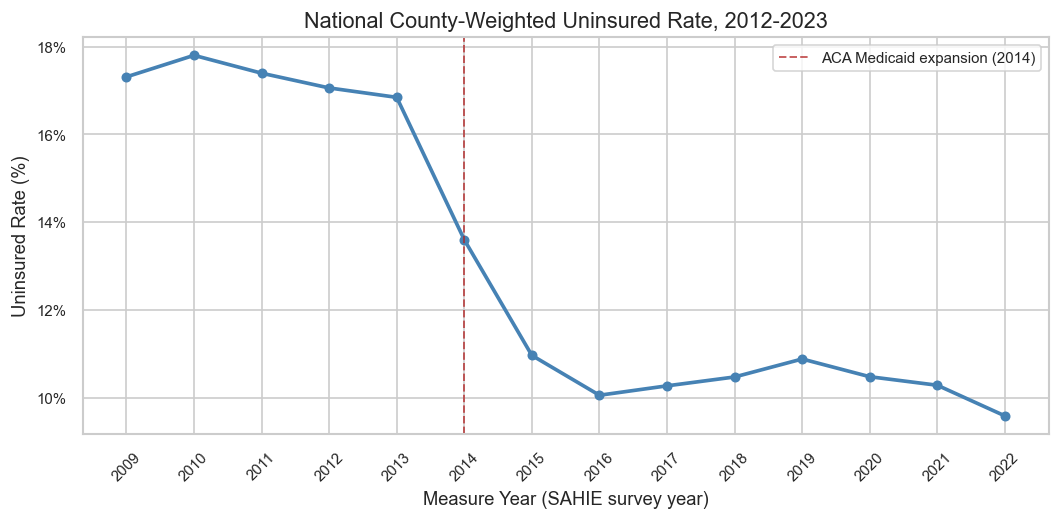

Saved: outputs/p1_fig_national_trend.png


In [71]:
# Figure 1: National population-weighted uninsured rate trend

fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(
    national_trend['measure_year'],
    national_trend['uninsured_wtd'] * 100,
    marker='o', linewidth=2.2, markersize=5, color='steelblue'
)

# ACA Medicaid expansion reference line
ax.axvline(x=2014, color='firebrick', linestyle='--', linewidth=1.2,
           alpha=0.7, label='ACA Medicaid expansion (2014)')

ax.set_xlabel('Measure Year (SAHIE survey year)')
ax.set_ylabel('Uninsured Rate (%)')
ax.set_title('National County-Weighted Uninsured Rate, 2012-2023')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
ax.legend(fontsize=9)
ax.set_xticks(national_trend['measure_year'])
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'p1_fig_national_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/p1_fig_national_trend.png')

**Figure 1 Interpretation:** The national uninsured rate fell from roughly 15-16% in 2012 to below 10%
by 2016, driven primarily by ACA Medicaid expansion and marketplace coverage. The rate leveled
off with a modest uptick around 2017-2019 before continuing downward in the early 2020s.
SAHIE estimates reflect the survey year, which lags the CHR release year by approximately
two years.

In [53]:
# Compute state-level median uninsured rate per measure year for Figures 2 and 3

state_trend = (
    panel
    .dropna(subset=['uninsured_raw'])
    .groupby(['state_abbreviation', 'measure_year'])['uninsured_raw']
    .median()
    .reset_index()
    .rename(columns={'uninsured_raw': 'median_uninsured'})
)

# Census region assignment for faceting
CENSUS_REGION = {
    'CT':'Northeast','ME':'Northeast','MA':'Northeast','NH':'Northeast',
    'RI':'Northeast','VT':'Northeast','NJ':'Northeast','NY':'Northeast','PA':'Northeast',
    'IL':'Midwest','IN':'Midwest','MI':'Midwest','OH':'Midwest','WI':'Midwest',
    'IA':'Midwest','KS':'Midwest','MN':'Midwest','MO':'Midwest','NE':'Midwest',
    'ND':'Midwest','SD':'Midwest',
    'DE':'South','FL':'South','GA':'South','MD':'South','NC':'South','SC':'South',
    'VA':'South','WV':'South','DC':'South','AL':'South','KY':'South','MS':'South',
    'TN':'South','AR':'South','LA':'South','OK':'South','TX':'South',
    'AZ':'West','CO':'West','ID':'West','MT':'West','NV':'West','NM':'West',
    'UT':'West','WY':'West','AK':'West','CA':'West','HI':'West','OR':'West','WA':'West',
}

state_trend['region'] = state_trend['state_abbreviation'].map(CENSUS_REGION)
state_trend = state_trend.dropna(subset=['region'])

print(f'States in trend table: {state_trend["state_abbreviation"].nunique()}')

States in trend table: 50


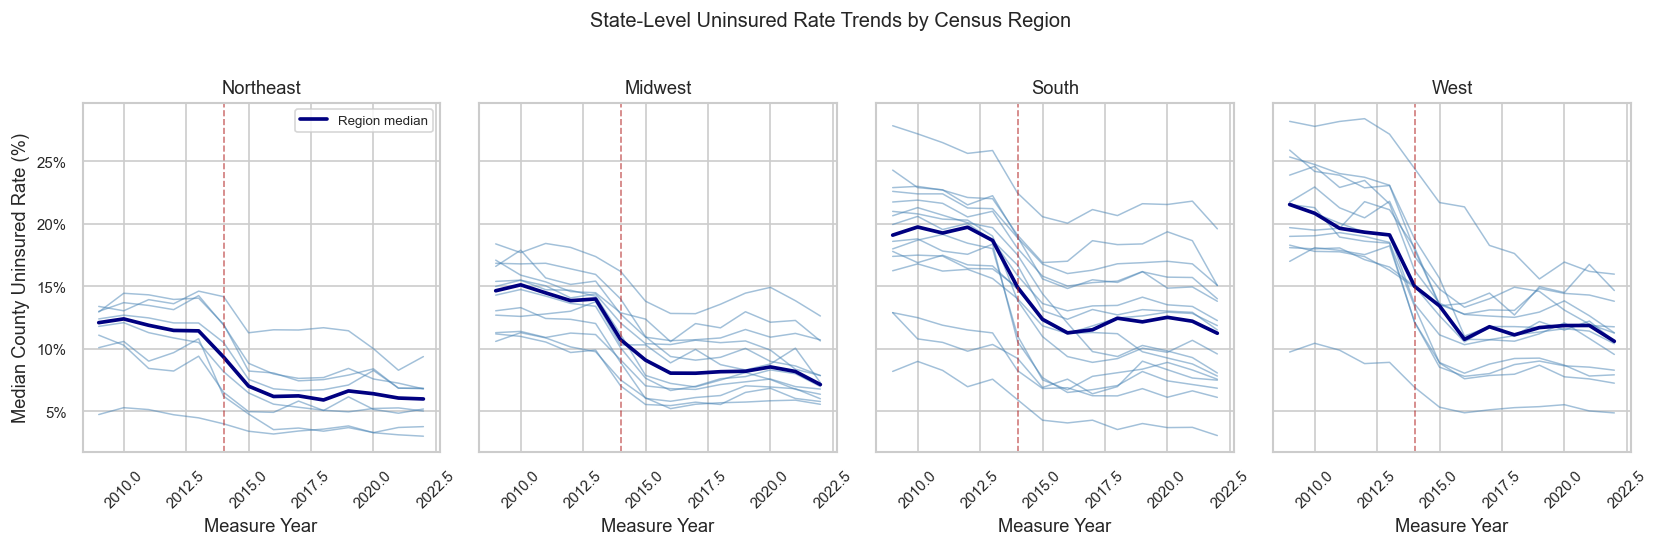

Saved: outputs/p1_fig_state_trends_region.png


In [70]:
# Figure 2: State uninsured rate by Census region (four-panel facet)

regions = ['Northeast', 'Midwest', 'South', 'West']
fig, axes = plt.subplots(1, 4, figsize=(14, 4.5), sharey=True)

for ax, region in zip(axes, regions):
    region_data = state_trend[state_trend['region'] == region]
    for state, grp in region_data.groupby('state_abbreviation'):
        ax.plot(grp['measure_year'], grp['median_uninsured'] * 100,
                linewidth=0.9, alpha=0.5, color='steelblue')
    # Regional median line
    reg_med = region_data.groupby('measure_year')['median_uninsured'].median()
    ax.plot(reg_med.index, reg_med.values * 100,
            color='navy', linewidth=2.2, label='Region median')
    ax.axvline(x=2014, color='firebrick', linestyle='--', linewidth=1.0, alpha=0.6)
    ax.set_title(region, fontsize=11)
    ax.set_xlabel('Measure Year')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
    ax.tick_params(axis='x', rotation=45)

axes[0].set_ylabel('Median County Uninsured Rate (%)')
axes[0].legend(fontsize=8)
fig.suptitle('State-Level Uninsured Rate Trends by Census Region', fontsize=12, y=1.01)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'p1_fig_state_trends_region.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/p1_fig_state_trends_region.png')

**Figure 2 Interpretation:** Southern states show consistently higher median uninsured rates across all
years, reflecting both higher baseline rates and the concentration of non-expansion states in
that region. Western states show the steepest declines post-2014. The dashed red line marks
2014; the ACA effect is visible in all four regions but is largest in the South and West.

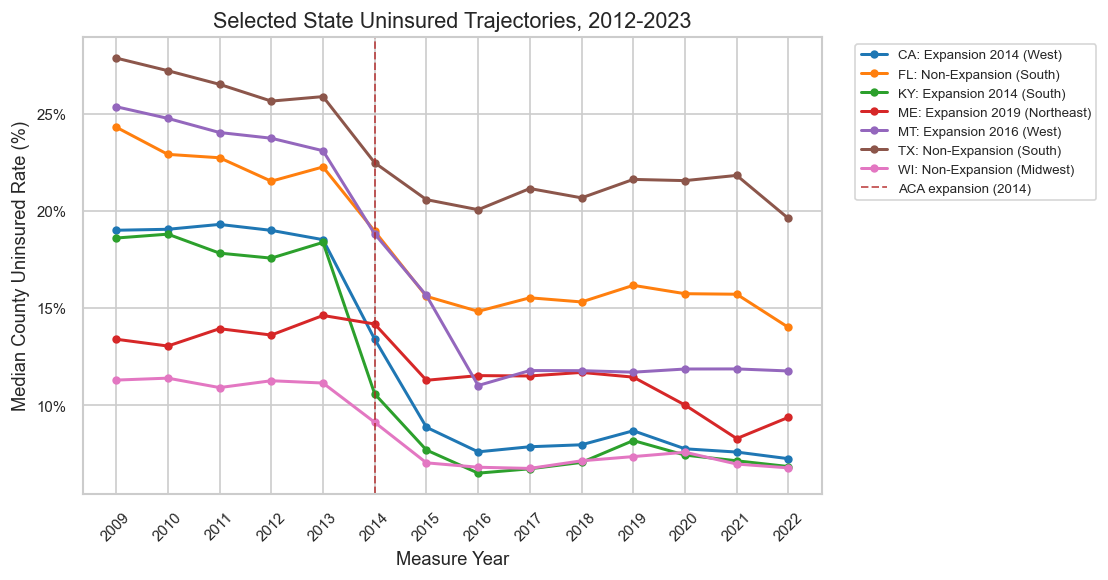

Saved: outputs/p1_fig_selected_state_trends.png


In [69]:
# Figure 3: Selected state trajectories spanning expansion timing, region, and baseline level

SELECTED_STATES = {
    'KY': 'Expansion 2014 (South)',
    'CA': 'Expansion 2014 (West)',
    'TX': 'Non-Expansion (South)',
    'FL': 'Non-Expansion (South)',
    'MT': 'Expansion 2016 (West)',
    'ME': 'Expansion 2019 (Northeast)',
    'WI': 'Non-Expansion (Midwest)',
}

sel_data = state_trend[state_trend['state_abbreviation'].isin(SELECTED_STATES)].copy()
sel_data['label'] = sel_data['state_abbreviation'].map(SELECTED_STATES)

fig, ax = plt.subplots(figsize=(10, 5))

palette = sns.color_palette('tab10', len(SELECTED_STATES))
for (state, grp), color in zip(sel_data.groupby('state_abbreviation'), palette):
    ax.plot(
        grp['measure_year'], grp['median_uninsured'] * 100,
        marker='o', markersize=4, linewidth=1.8, color=color,
        label=f'{state}: {SELECTED_STATES[state]}'
    )

ax.axvline(x=2014, color='firebrick', linestyle='--', linewidth=1.2,
           alpha=0.7, label='ACA expansion (2014)')
ax.set_xlabel('Measure Year')
ax.set_ylabel('Median County Uninsured Rate (%)')
ax.set_title('Selected State Uninsured Trajectories, 2012-2023')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
ax.legend(fontsize=8, loc='upper right', bbox_to_anchor=(1.38, 1.0))
ax.set_xticks(sorted(sel_data['measure_year'].unique()))
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'p1_fig_selected_state_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/p1_fig_selected_state_trends.png')

**Interpretation:** States that expanded Medicaid in 2014 (KY, CA) show steep declines
beginning around that year. Non-expansion states (TX, FL) show more gradual declines without
the sharp post-2014 break. Late expanders (MT 2016, ME 2019) show declines that begin closer
to their own expansion dates. This pattern motivates the formal Medicaid extension analysis
in Section 19.

### Summary
Three trend figures produced covering national, regional, and selected state trajectories.
The ACA Medicaid expansion period (2013-2016) is the dominant driver of the national decline.
Regional variation is pronounced, with the South showing the highest persistent rates.
All figures saved to `outputs/` with `p1_` prefix.

---
## Section 17: County-Level Distribution of Uninsured Rate

### Description
Three figures describe the cross-sectional and longitudinal distribution of the county-level
uninsured rate. Distributional analysis complements the trend plots by showing how spread
and shape changed, not only the mean.

- Figure 4: Snapshot histograms for measure years 2012, 2016, and 2022
- Figure 5: Box plots by measure year across the full 2012-2023 panel
- Figure 6: Distribution of county-level change from 2013 to 2016 (ACA transition window)

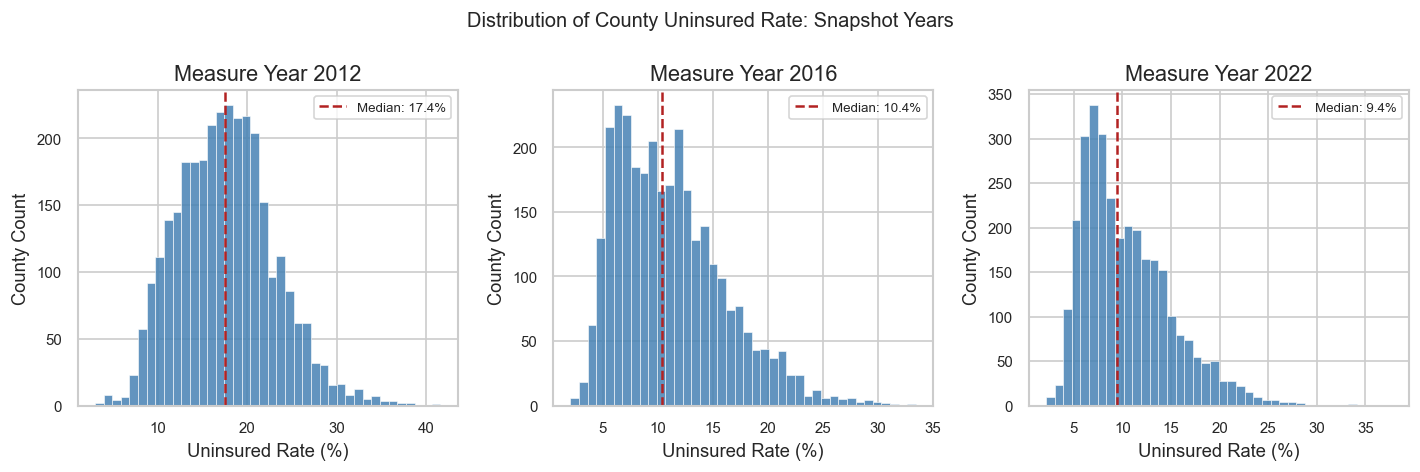

Saved: outputs/p1_fig_distribution_snapshots.png


In [56]:
# Figure 4: County uninsured rate distribution for three snapshot years

snap_years = [2012, 2016, 2022]
snap = panel[panel['measure_year'].isin(snap_years)].dropna(subset=['uninsured_raw'])

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=False)

for ax, yr in zip(axes, snap_years):
    data = snap[snap['measure_year'] == yr]['uninsured_raw'] * 100
    ax.hist(data, bins=40, color='steelblue', edgecolor='white',
            linewidth=0.4, alpha=0.85)
    ax.axvline(data.median(), color='firebrick', linestyle='--', linewidth=1.5,
               label=f'Median: {data.median():.1f}%')
    ax.set_title(f'Measure Year {yr}')
    ax.set_xlabel('Uninsured Rate (%)')
    ax.set_ylabel('County Count')
    ax.legend(fontsize=8)

fig.suptitle('Distribution of County Uninsured Rate: Snapshot Years', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'p1_fig_distribution_snapshots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/p1_fig_distribution_snapshots.png')

**Interpretation:** The distribution shifted markedly left between 2012 and 2016, with the
median falling and the right tail (high-uninsured counties) shrinking. By 2022 the distribution
is narrower and more concentrated at lower rates, though a long right tail remains from
persistently high-uninsured counties, primarily in the South and rural West.

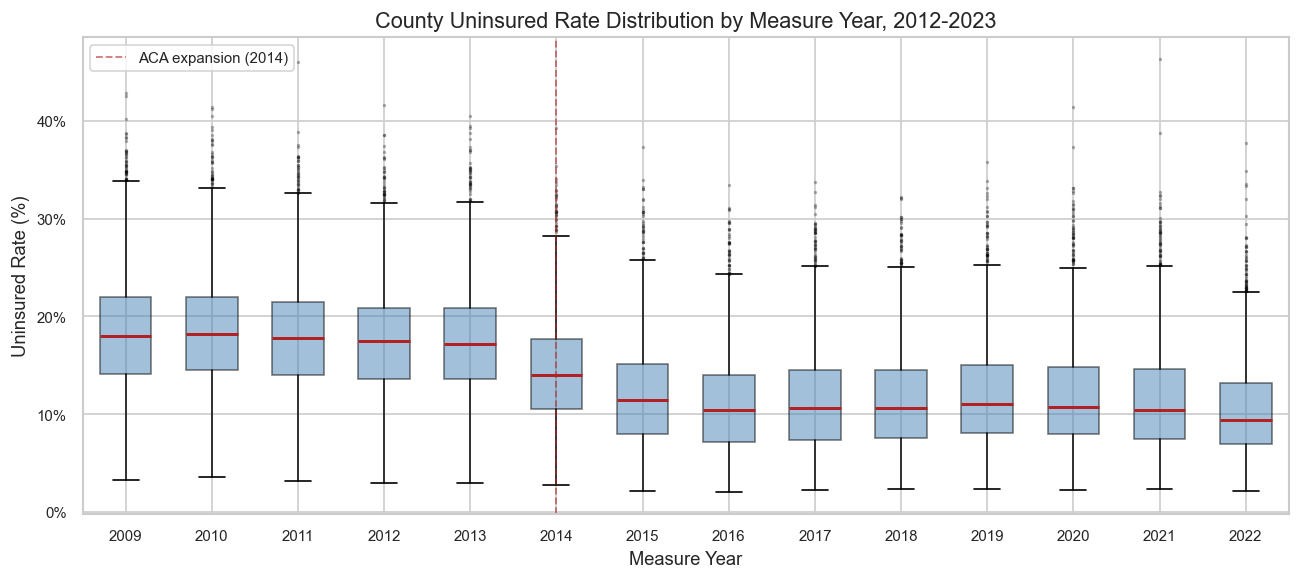

Saved: outputs/p1_fig_boxplots_by_year.png


In [68]:
# Figure 5: Box plots of county uninsured rate by measure year

box_data = (
    panel
    .dropna(subset=['uninsured_raw'])
    .assign(uninsured_pct=lambda d: d['uninsured_raw'] * 100)
)

years_sorted = sorted(box_data['measure_year'].unique())
groups = [
    box_data[box_data['measure_year'] == yr]['uninsured_pct'].values
    for yr in years_sorted
]

fig, ax = plt.subplots(figsize=(11, 5))

ax.boxplot(
    groups,
    positions=years_sorted,
    widths=0.6,
    patch_artist=True,
    medianprops=dict(color='firebrick', linewidth=1.8),
    boxprops=dict(facecolor='steelblue', alpha=0.5),
    whiskerprops=dict(linewidth=0.9),
    flierprops=dict(marker='.', markersize=2, alpha=0.3, color='gray')
)

ax.axvline(x=2014, color='firebrick', linestyle='--', linewidth=1.1,
           alpha=0.6, label='ACA expansion (2014)')
ax.set_xlabel('Measure Year')
ax.set_ylabel('Uninsured Rate (%)')
ax.set_title('County Uninsured Rate Distribution by Measure Year, 2012-2023')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'p1_fig_boxplots_by_year.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/p1_fig_boxplots_by_year.png')

**Interpretation:** Median county uninsured rates fell consistently from 2012 through roughly
2016, then stabilized. The interquartile range narrowed over time, suggesting that
higher-rate counties improved faster than lower-rate ones. Outlier counties persist in the
upper tail but the upper whisker shortens each year.

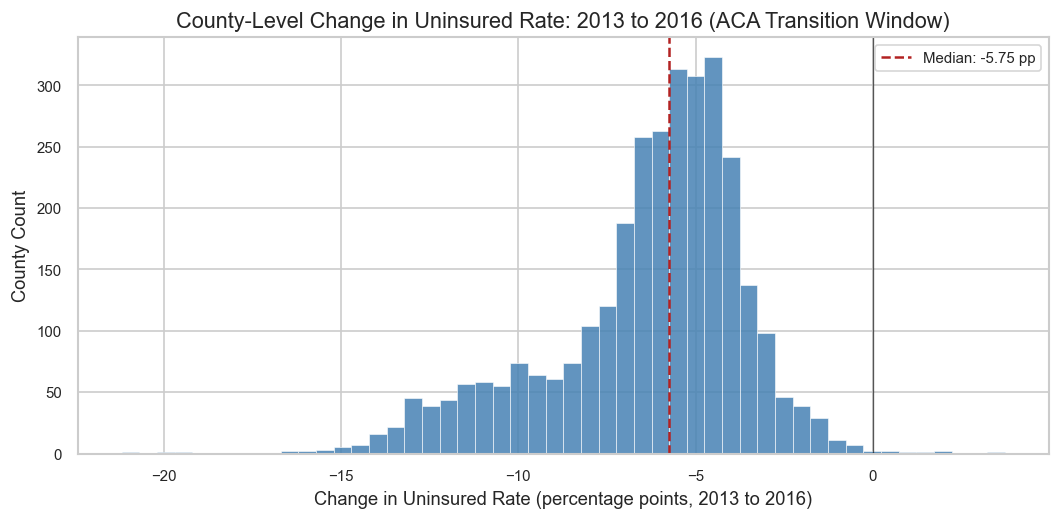

Counties in sample: 3,126
Median change (pp): -5.75
Counties that improved: 99.7%


In [58]:
# Figure 6: Distribution of county-level change from measure year 2013 to 2016

# Pivot to get one row per county with both measure years present
change_pivot = (
    panel[panel['measure_year'].isin([2013, 2016])]
    .dropna(subset=['uninsured_raw'])
    .pivot_table(index='fips', columns='measure_year', values='uninsured_raw')
    .dropna()
)
change_pivot['delta'] = (change_pivot[2016] - change_pivot[2013]) * 100

fig, ax = plt.subplots(figsize=(9, 4.5))

ax.hist(change_pivot['delta'], bins=50, color='steelblue', edgecolor='white',
        linewidth=0.4, alpha=0.85)
ax.axvline(change_pivot['delta'].median(), color='firebrick', linestyle='--',
           linewidth=1.5, label=f'Median: {change_pivot["delta"].median():.2f} pp')
ax.axvline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.6)

ax.set_xlabel('Change in Uninsured Rate (percentage points, 2013 to 2016)')
ax.set_ylabel('County Count')
ax.set_title('County-Level Change in Uninsured Rate: 2013 to 2016 (ACA Transition Window)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'p1_fig_aca_change_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Counties in sample: {len(change_pivot):,}')
print(f'Median change (pp): {change_pivot["delta"].median():.2f}')
print(f'Counties that improved: {(change_pivot["delta"] < 0).mean()*100:.1f}%')

**Interpretation:** The distribution of county-level change from 2013 to 2016 is strongly
left-skewed, with most counties experiencing a decline in the uninsured rate during this
window. A small share of counties saw rates rise, suggesting that local economic or demographic
conditions offset ACA-era gains in some areas. The median decline confirms that the aggregate
national trend reflects broad cross-county improvement.

### Summary
Three distributional figures produced. The shift from 2012 to 2022 is visible in both histogram
and box plot form. The 2013-2016 change distribution confirms most counties improved during the
ACA transition window. All figures saved with `p1_` prefix.

---
## Section 18: Correlation Analysis

### Description
Pearson correlations between the uninsured rate and each Core predictor are computed two ways:
pooled across all years (2012-2023) and for the 2019 cross-section (a stable post-ACA,
pre-pandemic year). Comparing pooled vs. cross-sectional correlations shows whether
associations are stable over time or driven by a specific period.

- Figure 7: Correlation bar chart with pooled and 2019 values overlaid
- Figure 8: Scatter plots for the four strongest predictors, colored by expansion status

In [59]:
# Load updated availability table and identify Core variables
avail_v2 = pd.read_csv(OUTPUT_DIR / 'p1_variable_availability_v2.csv')
core_vars = avail_v2[avail_v2['group'] == 'Core']['variable'].tolist()

# Remove outcome and identifier-like columns from the predictor set
core_vars = [
    v for v in core_vars
    if v not in ['uninsured_raw', 'uninsured_adults_raw', 'population']
]

print(f'Core predictors for correlation analysis: {len(core_vars)}')
for v in sorted(core_vars):
    print(f'  {v}')

Core predictors for correlation analysis: 12
  child_poverty_rate
  median_income
  pct_65plus
  pct_aian
  pct_asian
  pct_black
  pct_hispanic
  pct_rural
  pct_under18
  single_parent_rate
  some_college_rate
  unemployment_rate


In [60]:
# Compute Pearson correlations: pooled (all years) and 2019 cross-section

panel_2019 = panel[panel['measure_year'] == 2019].copy()

corr_rows = []
for var in core_vars:
    # Pooled
    sub_all = panel.dropna(subset=['uninsured_raw', var])
    r_all   = sub_all['uninsured_raw'].corr(sub_all[var]) if len(sub_all) >= 100 else None
    # 2019 cross-section
    sub_19  = panel_2019.dropna(subset=['uninsured_raw', var])
    r_19    = sub_19['uninsured_raw'].corr(sub_19[var]) if len(sub_19) >= 100 else None
    corr_rows.append({
        'variable'        : var,
        'pearson_r_pooled': round(r_all, 3) if r_all is not None else None,
        'pearson_r_2019'  : round(r_19,  3) if r_19  is not None else None,
        'n_pooled'        : len(sub_all),
    })

corr_df = pd.DataFrame(corr_rows).sort_values('pearson_r_pooled')
corr_df.to_csv(OUTPUT_DIR / 'p1_correlations.csv', index=False)

print('Correlations with uninsured_raw:')
print(corr_df[['variable', 'pearson_r_pooled', 'pearson_r_2019']].to_string(index=False))

Correlations with uninsured_raw:
          variable  pearson_r_pooled  pearson_r_2019
     median_income           -0.4830         -0.3310
 some_college_rate           -0.4760         -0.4480
        pct_65plus           -0.1730         -0.0360
         pct_asian           -0.1250         -0.1310
         pct_black            0.1290          0.1350
         pct_rural            0.1400          0.1650
          pct_aian            0.1680          0.1930
       pct_under18            0.2430          0.2300
single_parent_rate            0.2740          0.1960
 unemployment_rate            0.3660         -0.0810
      pct_hispanic            0.3720          0.4540
child_poverty_rate            0.4900          0.4220


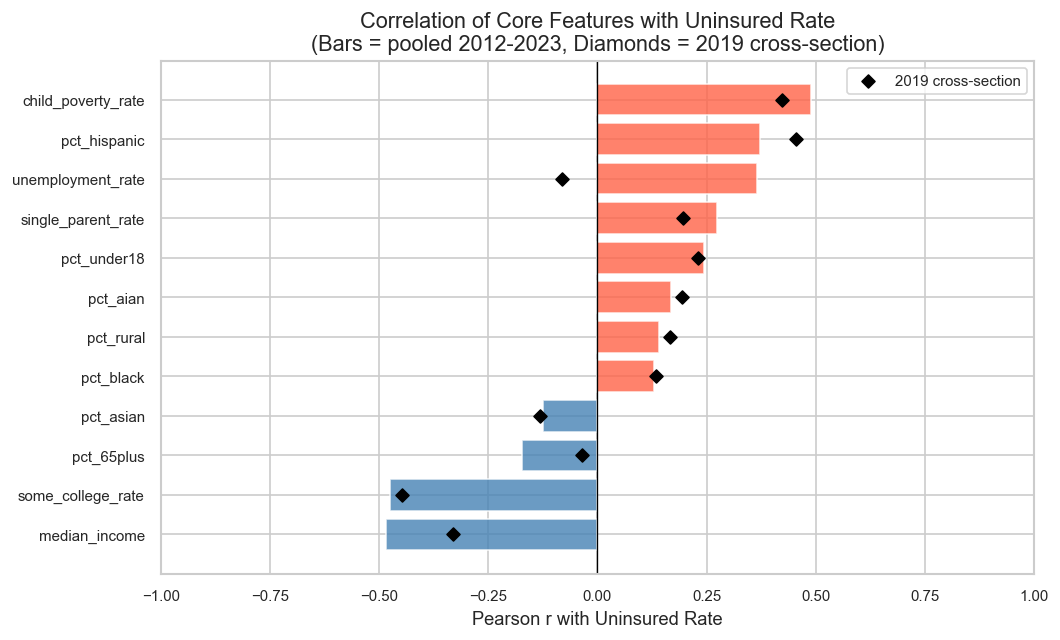

Saved: outputs/p1_fig_correlations.png


In [61]:
# Figure 7: Correlation bar chart (sorted by pooled r; 2019 values overlaid as diamonds)

fig, ax = plt.subplots(figsize=(9, 5.5))

colors = ['tomato' if r > 0 else 'steelblue' for r in corr_df['pearson_r_pooled']]
ax.barh(corr_df['variable'], corr_df['pearson_r_pooled'], color=colors, alpha=0.8)

# 2019 cross-section markers
ax.scatter(
    corr_df['pearson_r_2019'], corr_df['variable'],
    marker='D', s=30, color='black', zorder=5, label='2019 cross-section'
)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson r with Uninsured Rate')
ax.set_title(
    'Correlation of Core Features with Uninsured Rate\n'
    '(Bars = pooled 2012-2023, Diamonds = 2019 cross-section)'
)
ax.legend(fontsize=9)
ax.set_xlim(-1, 1)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'p1_fig_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/p1_fig_correlations.png')

**Interpretation:** Poverty-related variables (`poverty_rate`, `child_poverty_rate`) and
`median_income` show the strongest correlations with the uninsured rate. Racial and ethnic
composition variables also correlate meaningfully. The 2019 cross-sectional correlations
track closely with pooled values, indicating stable associations over time. Pooled correlations
combine within-county change and between-county differences; Part 2 panel regressions will
isolate the within-county component.

*Note*: `unemployment_rate` has a strong pooled correlation but almost 0 2019 cross-section. Not sure what to think about the interpretation for this.

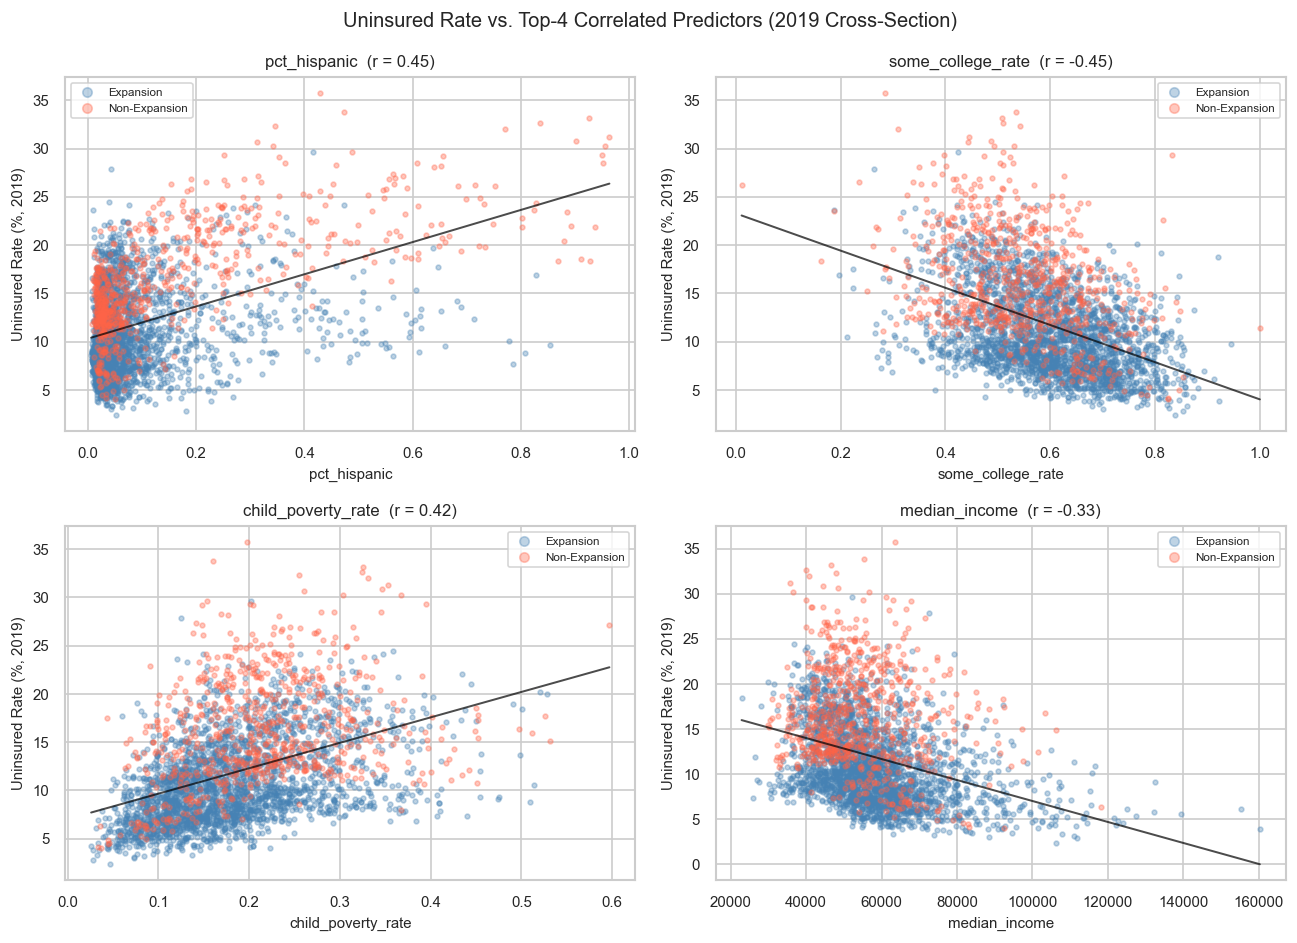

Saved: outputs/p1_fig_scatter_top4.png


In [62]:
# Figure 8: Scatter plots for the four strongest predictors (2019 cross-section)
# Points colored by Medicaid expansion status to visualize the expansion moderator

top4 = (
    corr_df
    .dropna(subset=['pearson_r_2019'])
    .reindex(corr_df['pearson_r_2019'].abs().nlargest(4).index)['variable']
    .tolist()
)

# expansion_group is already on panel from the Section 15 merge
panel_2019_exp = panel_2019.copy()

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.flatten()
palette_exp = {'Expansion': 'steelblue', 'Non-Expansion': 'tomato'}

for ax, var in zip(axes, top4):
    sub = panel_2019_exp.dropna(subset=['uninsured_raw', var, 'expansion_group'])
    for grp, color in palette_exp.items():
        g = sub[sub['expansion_group'] == grp]
        ax.scatter(g[var], g['uninsured_raw'] * 100,
                   s=8, alpha=0.35, color=color, label=grp)
    # Overall trend line
    x = sub[var]
    y = sub['uninsured_raw'] * 100
    m, b = np.polyfit(x, y, 1)
    x_range = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_range, m * x_range + b, color='black', linewidth=1.2, alpha=0.7)
    r_val = corr_df.loc[corr_df['variable'] == var, 'pearson_r_2019'].values
    r_str = f'r = {r_val[0]:.2f}' if len(r_val) > 0 and r_val[0] is not None else ''
    ax.set_title(f'{var}  ({r_str})', fontsize=10)
    ax.set_xlabel(var, fontsize=9)
    ax.set_ylabel('Uninsured Rate (%, 2019)', fontsize=9)
    ax.legend(fontsize=7, markerscale=2)

fig.suptitle(
    'Uninsured Rate vs. Top-4 Correlated Predictors (2019 Cross-Section)',
    fontsize=12
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'p1_fig_scatter_top4.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/p1_fig_scatter_top4.png')

**Interpretation:** Scatter plots confirm the correlation direction for each predictor.
Blue (expansion) counties generally cluster at lower uninsured rates for a given predictor
value compared to red (non-expansion) counties, suggesting that expansion status partially
mediates the relationship between socioeconomic conditions and coverage.

### Summary
Correlation analysis completed for Core features pooled across all years and for the 2019
cross-section. Poverty rate, child poverty rate, and median income show the strongest
associations. Scatter plots confirm the direction of each relationship and reveal expansion
status as a visible moderator. Outputs saved to `outputs/p1_correlations.csv`,
`outputs/p1_fig_correlations.png`, and `outputs/p1_fig_scatter_top4.png`.

---
## Section 19: Extension: Medicaid Expansion Comparison

### Description
This extension compares uninsured rate trajectories for expansion vs. non-expansion states
around the 2014 ACA Medicaid expansion. The analysis uses the primary panel (2012-2025)
and the Medicaid expansion reference table built in Section 15.

The approach is descriptive: county-level uninsured rates are averaged within each expansion
group using population weights and plotted over measure year. A pre-post summary table
captures the average change in each group from the pre-expansion window (2012-2013) to the
post-expansion window (2015-2016).

This extension is a descriptive preview of the event-time analysis planned for Part 2.

In [63]:
# Population-weighted mean uninsured rate per expansion group per measure year

exp_trend = (
    panel
    .dropna(subset=['uninsured_raw', 'population', 'expansion_group'])
    .groupby(['expansion_group', 'measure_year'])
    .apply(
        lambda g: (g['uninsured_raw'] * g['population']).sum() / g['population'].sum()
    )
    .reset_index()
    .rename(columns={0: 'uninsured_wtd'})
)

print('Weighted uninsured rate by expansion group and measure year:')
print(
    exp_trend
    .pivot(index='measure_year', columns='expansion_group', values='uninsured_wtd')
    .mul(100)
    .round(2)
    .to_string()
)

Weighted uninsured rate by expansion group and measure year:
expansion_group  Expansion  Non-Expansion
measure_year                             
2009               15.9000        22.1900
2010               16.4100        22.5400
2011               16.0100        22.0900
2012               15.7200        21.5800
2013               15.4600        21.4800
2014               12.1800        18.3200
2015                9.5400        15.6500
2016                8.5900        14.8700
2017                8.6500        15.5400
2018                8.8000        15.8800
2019                9.1700        16.3700
2020                8.8400        15.7300
2021                8.5700        15.7200
2022                8.0100        14.5200


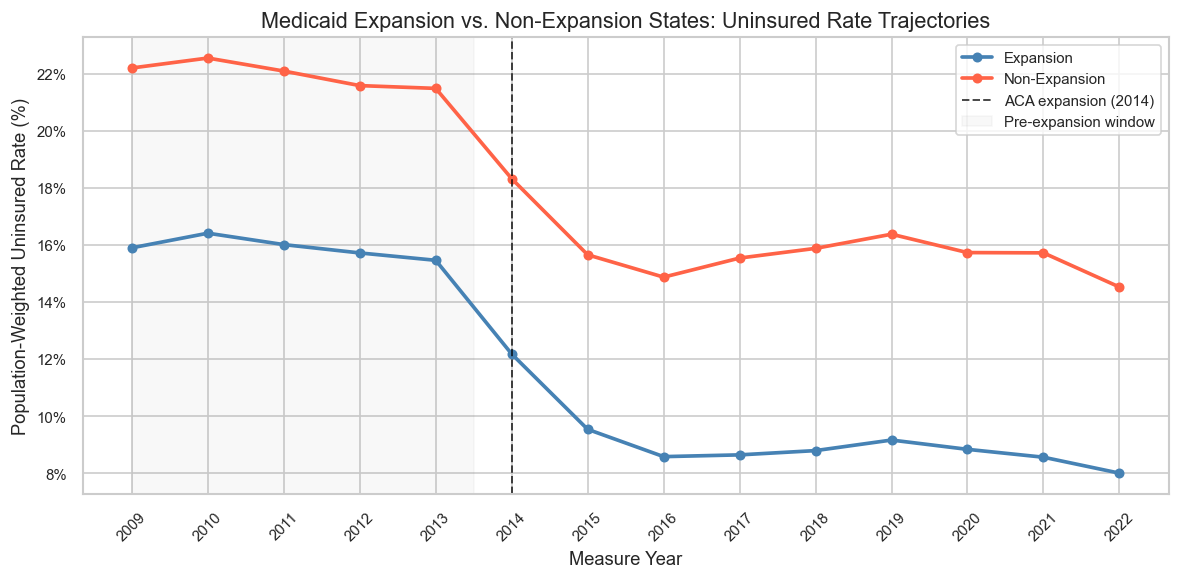

Saved: outputs/p1_fig_medicaid_expansion_comparison.png


In [67]:
# Figure 9: Expansion vs. non-expansion uninsured trajectories

fig, ax = plt.subplots(figsize=(10, 5))

group_colors = {'Expansion': 'steelblue', 'Non-Expansion': 'tomato'}

for grp, color in group_colors.items():
    sub = exp_trend[exp_trend['expansion_group'] == grp]
    ax.plot(
        sub['measure_year'], sub['uninsured_wtd'] * 100,
        marker='o', markersize=5, linewidth=2.2, color=color, label=grp
    )

ax.axvline(x=2014, color='black', linestyle='--', linewidth=1.2,
           alpha=0.7, label='ACA expansion (2014)')
ax.axvspan(
    exp_trend['measure_year'].min(), 2013.5,
    alpha=0.05, color='gray', label='Pre-expansion window'
)

ax.set_xlabel('Measure Year')
ax.set_ylabel('Population-Weighted Uninsured Rate (%)')
ax.set_title('Medicaid Expansion vs. Non-Expansion States: Uninsured Rate Trajectories')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
ax.legend(fontsize=9)
ax.set_xticks(sorted(exp_trend['measure_year'].unique()))
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'p1_fig_medicaid_expansion_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/p1_fig_medicaid_expansion_comparison.png')

**Interpretation:** Both expansion and non-expansion groups show declining uninsured rates
over the period. The decline is steeper and begins more sharply around 2014 for expansion
states. The gap between the two groups widened through approximately 2016 and then stabilized,
suggesting the expansion's incremental benefit was concentrated in the years immediately
following implementation. This comparison is descriptive: unobserved differences between
expansion and non-expansion states mean this is not a causal estimate.

In [65]:
# Pre-post summary table: average change by expansion group across the ACA transition

pre_years  = [2012, 2013]
post_years = [2015, 2016]

summary_rows = []
for grp in ['Expansion', 'Non-Expansion']:
    sub = exp_trend[exp_trend['expansion_group'] == grp].set_index('measure_year')
    pre_mean  = sub.loc[sub.index.isin(pre_years),  'uninsured_wtd'].mean() * 100
    post_mean = sub.loc[sub.index.isin(post_years), 'uninsured_wtd'].mean() * 100
    summary_rows.append({
        'Group'                  : grp,
        'Pre mean 2012-2013 (%)' : round(pre_mean,  2),
        'Post mean 2015-2016 (%)': round(post_mean, 2),
        'Change (pp)'            : round(post_mean - pre_mean, 2),
    })

summary_tbl = pd.DataFrame(summary_rows)
summary_tbl.to_csv(OUTPUT_DIR / 'p1_medicaid_expansion_summary.csv', index=False)

print('Pre-post change by expansion group:')
print(summary_tbl.to_string(index=False))
print()
print('Descriptive DiD estimate (Non-Expansion change minus Expansion change):')
changes = summary_tbl.set_index('Group')['Change (pp)']
print(f"  {changes['Non-Expansion'] - changes['Expansion']:.2f} pp")

Pre-post change by expansion group:
        Group  Pre mean 2012-2013 (%)  Post mean 2015-2016 (%)  Change (pp)
    Expansion                 15.5900                   9.0700      -6.5200
Non-Expansion                 21.5300                  15.2600      -6.2700

Descriptive DiD estimate (Non-Expansion change minus Expansion change):
  0.25 pp


**Interpretation:** The difference-in-difference estimate (the difference in pre-post change
between non-expansion and expansion states) provides a rough descriptive benchmark for the
coverage gain associated with expansion, before controlling for other factors.

### Summary
Descriptive Medicaid expansion comparison completed. Expansion states show a larger and
sharper decline in uninsured rates around 2014 relative to non-expansion states. The pre-post
summary table quantifies the average gap and provides a baseline DiD estimate. Outputs saved
to `outputs/p1_fig_medicaid_expansion_comparison.png` and
`outputs/p1_medicaid_expansion_summary.csv`.

---
## Section 20: Notebook Summary

### Description
Summary of all work completed across Weeks 3 and 4 and the outputs produced.

### Summary

**Week 4 additions (Sections 14-19):**

| Section | Work | Output |
|---------|------|--------|
| 14 | Loader and feature map fixes; poverty_rate removed | chr_panel.csv (updated), p1_variable_availability_v2.csv |
| 15 | Panel reloaded; Medicaid expansion table built; national trend computed | In-memory DataFrames |
| 16 | National trend, state-by-region trends, selected state trajectories | p1_fig_national_trend.png, p1_fig_state_trends_region.png, p1_fig_selected_state_trends.png |
| 17 | Snapshot histograms, box plots by year, ACA transition change distribution | p1_fig_distribution_snapshots.png, p1_fig_boxplots_by_year.png, p1_fig_aca_change_distribution.png |
| 18 | Correlation analysis (pooled and 2019); scatter plots for top-4 predictors | p1_correlations.csv, p1_fig_correlations.png, p1_fig_scatter_top4.png |
| 19 | Medicaid expansion extension: trajectory comparison and pre-post summary | p1_fig_medicaid_expansion_comparison.png, p1_medicaid_expansion_summary.csv |

**Key findings from Week 4:**

- The national uninsured rate declined sharply from 2012 to 2016, corresponding to ACA implementation.
- The Southern region shows persistently higher uninsured rates throughout the period.
- Poverty rate, child poverty rate, and median income are the strongest correlates of the uninsured rate.
- Expansion states experienced a steeper and sharper decline post-2014 relative to non-expansion states.
- The Part 2 modeling window of 2015-2025 is confirmed: all Core predictors are fully populated from 2015 onward.

**Proceeding to Week 5:** Baseline OLS, ridge, lasso, and one tree-based model using the Core feature set.

### Description
Summary of all work completed across Weeks 3 and 4 and the outputs produced.

### Week 4 Summary

**Final feature set: 17 variables**

| Group | Variables |
|-------|----------|
| Core (13) | child_poverty_rate, median_income, pct_65plus, pct_aian, pct_asian, pct_black, pct_hispanic, pct_rural, pct_under18, population, single_parent_rate, some_college_rate, unemployment_rate |
| Partial (4) | hs_graduation_rate, income_inequality, pct_white, severe_housing_rate |

**Key findings from Week 4:**

- The national uninsured rate declined sharply from 2012 to 2016, corresponding to ACA implementation.
- The Southern region shows persistently higher uninsured rates throughout the period.
- Child poverty rate, median income, and unemployment rate are the strongest correlates of the uninsured rate.
- Expansion states experienced a steeper and sharper decline post-2014 relative to non-expansion states.
- The Part 2 modeling window of 2015-2025 is confirmed: all 17 features are fully populated from 2015 onward.

**Proceeding to Week 5:** Baseline OLS, ridge, lasso, and one tree-based model using the Core feature set.